# Bengaluru Real Estate Analysis & Price Predictor
End-to-end project: data cleaning, EDA, outlier removal, model comparison (Linear vs Lasso vs Ridge), and Flask deployment.

In [71]:
import numpy as np
import pandas as pd
import sklearn
import os
os.makedirs('screenshots', exist_ok=True)
print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("sklearn:", sklearn.__version__)
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

numpy: 1.23.5
pandas: 2.3.3
sklearn: 1.7.2


## Data Loading
Loaded 13,320 raw property listings from Bengaluru.

In [8]:
data=pd.read_csv('Bengaluru_House_data.csv')

## Initial Inspection
Checked shape, dtypes, and missing values to plan the cleaning steps.

In [9]:
data.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [10]:
data.shape

(13320, 9)

In [11]:
for column in data.columns:
    print(data[column].value_counts())
    print("*"*20)

area_type
Super built-up  Area    8790
Built-up  Area          2418
Plot  Area              2025
Carpet  Area              87
Name: count, dtype: int64
********************
availability
Ready To Move    10581
18-Dec             307
18-May             295
18-Apr             271
18-Aug             200
                 ...  
15-Aug               1
17-Jan               1
16-Nov               1
16-Jan               1
14-Jul               1
Name: count, Length: 81, dtype: int64
********************
location
Whitefield                        540
Sarjapur  Road                    399
Electronic City                   302
Kanakpura Road                    273
Thanisandra                       234
                                 ... 
Bapuji Layout                       1
1st Stage Radha Krishna Layout      1
BEML Layout 5th stage               1
singapura paradise                  1
Abshot Layout                       1
Name: count, Length: 1305, dtype: int64
********************
size
2 BHK    

## Exploratory Data Analysis
Visualized price distribution, top locations, BHK pricing patterns, and feature correlations on the cleaned dataset.

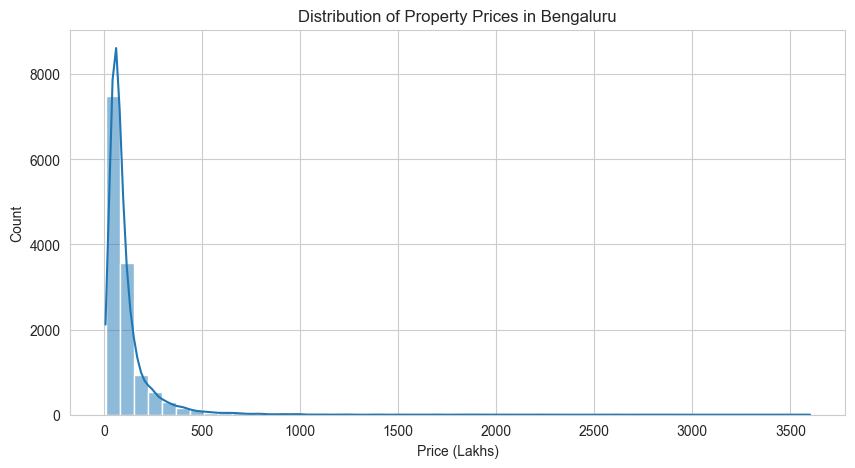

In [ ]:
# Chart 1: Price distribution
plt.figure(figsize=(10,5))
sns.histplot(data['price'], bins=50, kde=True)
plt.title('Distribution of Property Prices in Bengaluru')
plt.xlabel('Price (Lakhs)')
plt.savefig('screenshots/01_price_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

C:\Users\admin\AppData\Local\Temp\ipykernel_24488\3538496420.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_locations.values, y=top_10_locations.index, palette='viridis')


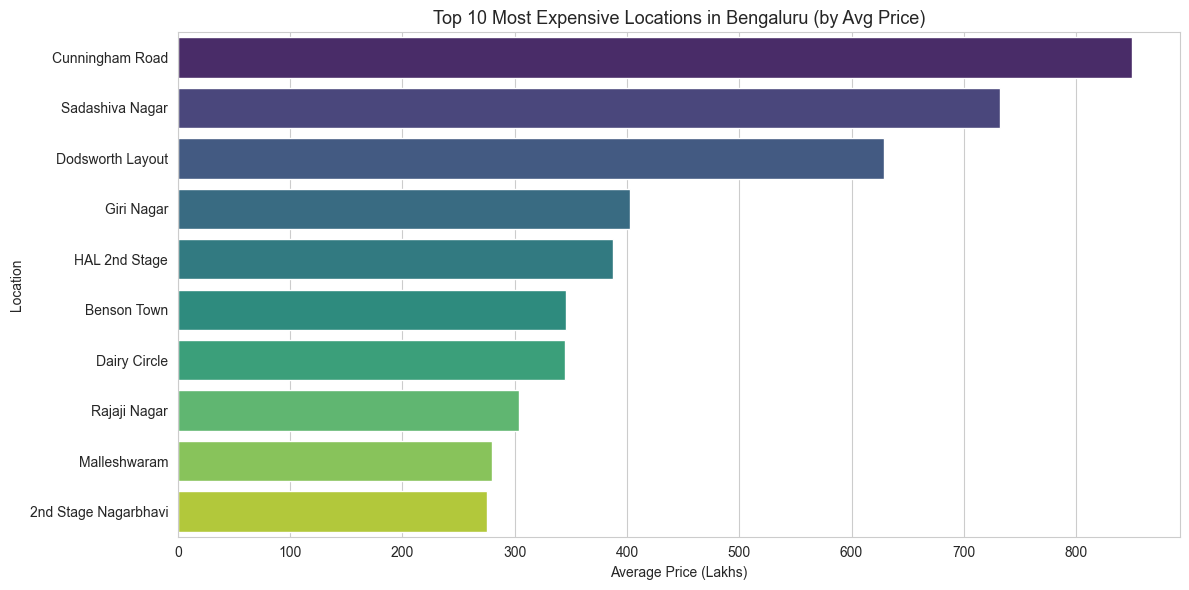

Insight: Cunningham Road tops the list at ₹850 Lakhs avg.


In [ ]:
top_10_locations = (
    data.groupby('location')['price']
        .mean()
        .sort_values(ascending=False)
        .head(10)
)
plt.figure(figsize=(12, 6))
sns.barplot(x=top_10_locations.values, y=top_10_locations.index, palette='viridis')
plt.title('Top 10 Most Expensive Locations in Bengaluru (by Avg Price)', fontsize=13)
plt.xlabel('Average Price (Lakhs)')
plt.ylabel('Location')
plt.tight_layout()
plt.savefig('screenshots/02_top_locations.png', dpi=100, bbox_inches='tight')
plt.show()
print("Insight:", top_10_locations.index[0], "tops the list at",
      f"₹{top_10_locations.iloc[0]:.0f} Lakhs avg.")

C:\Users\admin\AppData\Local\Temp\ipykernel_24488\232444619.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='bhk', y='price', data=common_bhk, palette='Set2')


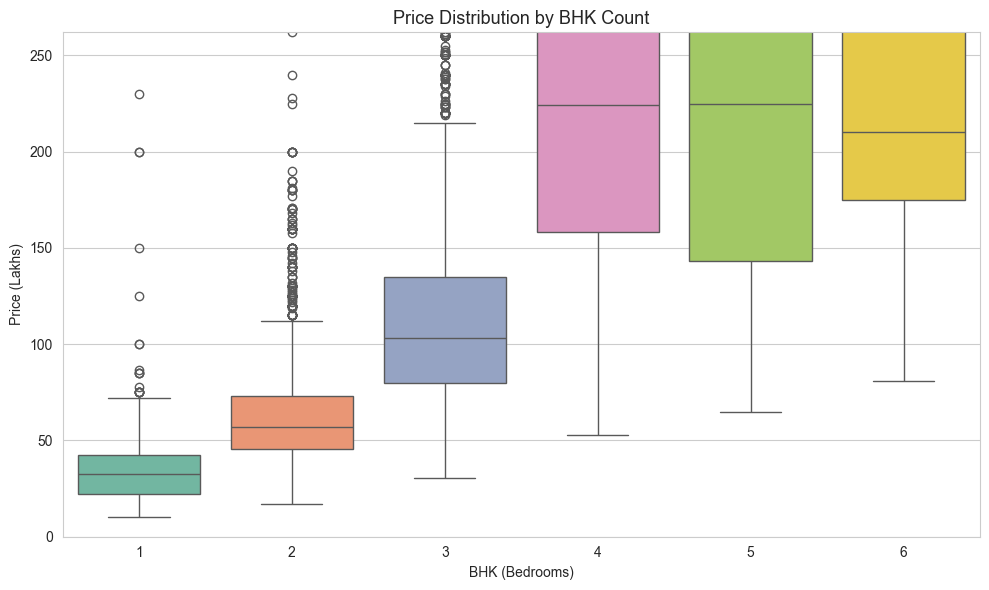

Insight: median price grows non-linearly with BHK — biggest jump usually between 2 and 3 BHK.


In [ ]:
# Filter to common BHK values to keep chart readable
common_bhk = data[data['bhk'].between(1, 6)]
plt.figure(figsize=(10, 6))
sns.boxplot(x='bhk', y='price', data=common_bhk, palette='Set2')
plt.title('Price Distribution by BHK Count', fontsize=13)
plt.xlabel('BHK (Bedrooms)')
plt.ylabel('Price (Lakhs)')
plt.ylim(0, common_bhk['price'].quantile(0.95))  # cut top 5% outliers for readability
plt.tight_layout()
plt.savefig('screenshots/03_price_by_bhk.png', dpi=100, bbox_inches='tight')
plt.show()
print("Insight: median price grows non-linearly with BHK — biggest jump usually between 2 and 3 BHK.")

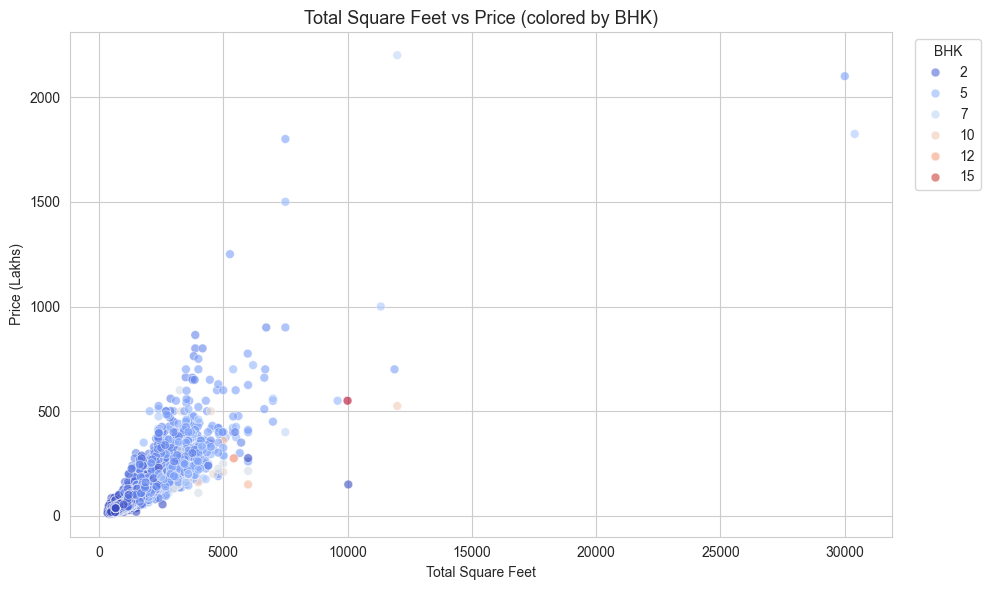

Insight: sqft and price correlate at 0.84 — strong positive relationship, as expected.


In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='total_sqft', y='price',
    hue='bhk', data=data,
    palette='coolwarm', alpha=0.6, s=40
)
plt.title('Total Square Feet vs Price (colored by BHK)', fontsize=13)
plt.xlabel('Total Square Feet')
plt.ylabel('Price (Lakhs)')
plt.legend(title='BHK', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig('screenshots/04_sqft_vs_price.png', dpi=100, bbox_inches='tight')
plt.show()
correlation = data['total_sqft'].corr(data['price'])
print(f"Insight: sqft and price correlate at {correlation:.2f} — strong positive relationship, as expected.")

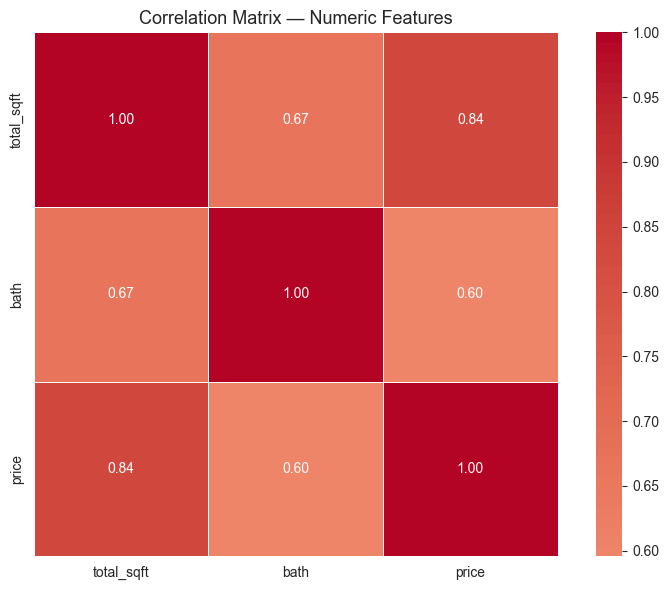

Insight: total_sqft is the strongest predictor of price; bath and bhk also correlate moderately.


In [75]:
numeric_cols = data.select_dtypes(include=['int64', 'float64'])
corr_matrix = numeric_cols.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,           # show numbers in each cell
    cmap='coolwarm',
    center=0,
    fmt='.2f',
    square=True,
    linewidths=0.5
)
plt.title('Correlation Matrix — Numeric Features', fontsize=13)
plt.tight_layout()
plt.savefig('screenshots/05_correlation_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()

print("Insight: total_sqft is the strongest predictor of price; bath and bhk also correlate moderately.")

## Data Cleaning
Dropped low-signal columns (area_type, availability, society, balcony) and filled missing values for location, size, and bath.

In [13]:
data.isna().sum()

area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64

In [14]:
data.drop(columns=['area_type','availability','society','balcony'],inplace=True)

In [15]:
data.describe()

,bath,price
count,13247.000000,13320.000000
mean,2.692610,112.565627
std,1.341458,148.971674
min,1.000000,8.000000
25%,2.000000,50.000000
50%,2.000000,72.000000
75%,3.000000,120.000000
max,40.000000,3600.000000


In [16]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   location    13319 non-null  object 
 1   size        13304 non-null  object 
 2   total_sqft  13320 non-null  object 
 3   bath        13247 non-null  float64
 4   price       13320 non-null  float64
dtypes: float64(2), object(3)
memory usage: 520.4+ KB


In [17]:
data['location'].value_counts()

location
Whitefield                        540
Sarjapur  Road                    399
Electronic City                   302
Kanakpura Road                    273
Thanisandra                       234
                                 ... 
Bapuji Layout                       1
1st Stage Radha Krishna Layout      1
BEML Layout 5th stage               1
singapura paradise                  1
Abshot Layout                       1
Name: count, Length: 1305, dtype: int64

In [18]:
data['location']=data['location'].fillna("sarjapur Road")

In [19]:
data['size'].value_counts()

size
2 BHK         5199
3 BHK         4310
4 Bedroom      826
4 BHK          591
3 Bedroom      547
1 BHK          538
2 Bedroom      329
5 Bedroom      297
6 Bedroom      191
1 Bedroom      105
8 Bedroom       84
7 Bedroom       83
5 BHK           59
9 Bedroom       46
6 BHK           30
7 BHK           17
1 RK            13
10 Bedroom      12
9 BHK            8
8 BHK            5
11 BHK           2
11 Bedroom       2
10 BHK           2
14 BHK           1
13 BHK           1
12 Bedroom       1
27 BHK           1
43 Bedroom       1
16 BHK           1
19 BHK           1
18 Bedroom       1
Name: count, dtype: int64

In [20]:
data['size']=data['size'].fillna("2 BHK")

In [21]:
data['bath']=data['bath'].fillna(data['bath'].median())

## Feature Engineering
Extracted BHK from the size column and converted total_sqft from string ranges to numeric values.

In [22]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   location    13320 non-null  object 
 1   size        13320 non-null  object 
 2   total_sqft  13320 non-null  object 
 3   bath        13320 non-null  float64
 4   price       13320 non-null  float64
dtypes: float64(2), object(3)
memory usage: 520.4+ KB


In [23]:
data['bhk']=data['size'].str.split().str.get(0).astype(int)

In [24]:
data[data.bhk>20]

,location,size,total_sqft,bath,price,bhk
1718,2Electronic City Phase II,27 BHK,8000,27.0,230.0,27
4684,Munnekollal,43 Bedroom,2400,40.0,660.0,43


In [25]:
data['total_sqft'].unique()

array(['1056', '2600', '1440', ..., '1133 - 1384', '774', '4689'],
      dtype=object)

In [26]:
def convertRange(x):
    temp=x.split('-')
    if len(temp)==2:
        return (float(temp[0])+float(temp[1]))//2
    try:
        return float(x)
    except:
        return None

In [27]:
data['total_sqft']=data['total_sqft'].apply(convertRange)

In [28]:
data.head

<bound method NDFrame.head of                        location       size  total_sqft  bath   price  bhk
0      Electronic City Phase II      2 BHK      1056.0   2.0   39.07    2
1              Chikka Tirupathi  4 Bedroom      2600.0   5.0  120.00    4
2                   Uttarahalli      3 BHK      1440.0   2.0   62.00    3
3            Lingadheeranahalli      3 BHK      1521.0   3.0   95.00    3
4                      Kothanur      2 BHK      1200.0   2.0   51.00    2
...                         ...        ...         ...   ...     ...  ...
13315                Whitefield  5 Bedroom      3453.0   4.0  231.00    5
13316             Richards Town      4 BHK      3600.0   5.0  400.00    4
13317     Raja Rajeshwari Nagar      2 BHK      1141.0   2.0   60.00    2
13318           Padmanabhanagar      4 BHK      4689.0   4.0  488.00    4
13319              Doddathoguru      1 BHK       550.0   1.0   17.00    1

[13320 rows x 6 columns]>

In [29]:
data['price_per_sqft']=data['price']*100000/data['total_sqft']

In [30]:
data['price_per_sqft']

0         3699.810606
1         4615.384615
2         4305.555556
3         6245.890861
4         4250.000000
             ...     
13315     6689.834926
13316    11111.111111
13317     5258.545136
13318    10407.336319
13319     3090.909091
Name: price_per_sqft, Length: 13320, dtype: float64

In [31]:
data.describe()

,total_sqft,bath,price,bhk,price_per_sqft
count,13274.000000,13320.000000,13320.000000,13320.000000,1.327400e+04
mean,1559.623410,2.688814,112.565627,2.802778,7.907513e+03
std,1238.404503,1.338754,148.971674,1.294496,1.064296e+05
min,1.000000,1.000000,8.000000,1.000000,2.678298e+02
25%,1100.000000,2.000000,50.000000,2.000000,4.266865e+03
50%,1276.000000,2.000000,72.000000,3.000000,5.434306e+03
75%,1680.000000,3.000000,120.000000,3.000000,7.311746e+03
max,52272.000000,40.000000,3600.000000,43.000000,1.200000e+07


In [32]:
data['location'].value_counts()

location
Whitefield                        540
Sarjapur  Road                    399
Electronic City                   302
Kanakpura Road                    273
Thanisandra                       234
                                 ... 
1st Stage Radha Krishna Layout      1
BEML Layout 5th stage               1
singapura paradise                  1
Uvce Layout                         1
Abshot Layout                       1
Name: count, Length: 1306, dtype: int64

In [33]:
data['location']=data['location'].apply(lambda x: x.strip())
location_count=data['location'].value_counts()
location_count

location
Whitefield                            541
Sarjapur  Road                        399
Electronic City                       304
Kanakpura Road                        273
Thanisandra                           237
                                     ... 
1Channasandra                           1
Hosahalli                               1
Vijayabank bank layout                  1
near Ramanashree California resort      1
Abshot Layout                           1
Name: count, Length: 1295, dtype: int64

In [34]:
location_count_less_10=location_count[location_count<10]
location_count_less_10

location
Volagerekallahalli                    9
Medahalli                             9
Vishwanatha Nagenahalli               9
2nd Phase JP Nagar                    9
Chennammana Kere                      9
                                     ..
1Channasandra                         1
Hosahalli                             1
Vijayabank bank layout                1
near Ramanashree California resort    1
Abshot Layout                         1
Name: count, Length: 1041, dtype: int64

In [35]:
data['location']=data['location'].apply(lambda x : 'Other' if x in location_count_less_10 else x)
data['location'].value_counts()

location
Other                  2756
Whitefield              541
Sarjapur  Road          399
Electronic City         304
Kanakpura Road          273
                       ... 
BTM 1st Stage            10
Basapura                 10
Sector 1 HSR Layout      10
Kalkere                  10
Nagadevanahalli          10
Name: count, Length: 255, dtype: int64

In [36]:
print("Outlier detection and removal")

Outlier detection and removal


In [37]:
data.describe()

,total_sqft,bath,price,bhk,price_per_sqft
count,13274.000000,13320.000000,13320.000000,13320.000000,1.327400e+04
mean,1559.623410,2.688814,112.565627,2.802778,7.907513e+03
std,1238.404503,1.338754,148.971674,1.294496,1.064296e+05
min,1.000000,1.000000,8.000000,1.000000,2.678298e+02
25%,1100.000000,2.000000,50.000000,2.000000,4.266865e+03
50%,1276.000000,2.000000,72.000000,3.000000,5.434306e+03
75%,1680.000000,3.000000,120.000000,3.000000,7.311746e+03
max,52272.000000,40.000000,3600.000000,43.000000,1.200000e+07


In [38]:
(data['total_sqft']/data['bhk']).describe()

count    13274.000000
mean       575.073303
std        388.204821
min          0.250000
25%        473.333333
50%        552.500000
75%        625.000000
max      26136.000000
dtype: float64

In [39]:
data=data[((data['total_sqft']/data['bhk'])>300)]
data.describe()

,total_sqft,bath,price,bhk,price_per_sqft
count,12348.000000,12348.000000,12348.000000,12348.000000,12348.000000
mean,1601.081159,2.542274,110.823169,2.633301,6207.882022
std,1268.787342,1.065177,152.794399,0.964402,4047.662719
min,340.000000,1.000000,8.440000,1.000000,267.829813
25%,1115.000000,2.000000,49.000000,2.000000,4200.000000
50%,1305.000000,2.000000,69.475000,3.000000,5264.632169
75%,1708.000000,3.000000,115.000000,3.000000,6825.108836
max,52272.000000,16.000000,3600.000000,16.000000,176470.588235


In [40]:
data.shape

(12348, 7)

In [41]:
data.price_per_sqft.describe()

count     12348.000000
mean       6207.882022
std        4047.662719
min         267.829813
25%        4200.000000
50%        5264.632169
75%        6825.108836
max      176470.588235
Name: price_per_sqft, dtype: float64

## Outlier Detection & Removal
Removed properties with sqft/BHK ratio under 300 and per-location price-per-sqft outliers beyond 1 standard deviation.

In [42]:
def remove_Outlier_sqft(df):
    df_output=pd.DataFrame()
    for key, subdf in df.groupby('location'):
        m=np.mean(subdf.price_per_sqft)
        st=np.std(subdf.price_per_sqft)
        gen_df=subdf[(subdf.price_per_sqft>(m-st))&(subdf.price_per_sqft<(m+st))]
        df_output=pd.concat([df_output,gen_df],ignore_index=True)
    return df_output
data=remove_Outlier_sqft(data)
data.describe()

,total_sqft,bath,price,bhk,price_per_sqft
count,10060.000000,10060.000000,10060.000000,10060.000000,10060.000000
mean,1511.065792,2.464314,91.432377,2.564115,5634.657280
std,884.443826,0.973053,88.507053,0.882367,2232.866277
min,350.000000,1.000000,10.000000,1.000000,1250.000000
25%,1110.000000,2.000000,49.000000,2.000000,4250.000000
50%,1290.000000,2.000000,67.000000,2.000000,5166.666667
75%,1650.000000,3.000000,100.000000,3.000000,6399.131271
max,30400.000000,16.000000,2200.000000,16.000000,24509.803922


In [43]:
def bhk_outlier_remover(df):
    exclude_indices=np.array([])
    for location, location_df in df.groupby('location'):
        bhk_stats={}
        for bhk, bhk_df in location_df.groupby('bhk'):
            bhk_stats[bhk]={
                'mean':np.mean(bhk_df.price_per_sqft),
                'std':np.std(bhk_df.price_per_sqft),
                'count':bhk_df.shape[0]
            }
        for bhk, bhk_df in location_df.groupby('bhk'):
            stats=bhk_stats.get(bhk-1)
            if stats and stats['count']>5:
                exclude_indices=np.append(exclude_indices,bhk_df[bhk_df.price_per_sqft<(stats['mean'])].index.values)
    return df.drop(exclude_indices,axis='index')

In [44]:
data=bhk_outlier_remover(data)

In [45]:
data.shape

(7248, 7)

In [46]:
data

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,1st Block Jayanagar,4 BHK,2850.0,4.0,428.0,4,15017.543860
1,1st Block Jayanagar,3 BHK,1630.0,3.0,194.0,3,11901.840491
2,1st Block Jayanagar,3 BHK,1875.0,2.0,235.0,3,12533.333333
3,1st Block Jayanagar,3 BHK,1200.0,2.0,130.0,3,10833.333333
4,1st Block Jayanagar,2 BHK,1235.0,2.0,148.0,2,11983.805668
...,...,...,...,...,...,...,...
10049,Yeshwanthpur,2 BHK,1195.0,2.0,100.0,2,8368.200837
10050,Yeshwanthpur,3 BHK,1692.0,3.0,108.0,3,6382.978723
10052,Yeshwanthpur,6 Bedroom,2500.0,5.0,185.0,6,7400.000000
10057,Yeshwanthpur,3 BHK,1855.0,3.0,135.0,3,7277.628032


In [47]:
data.drop(columns=['size','price_per_sqft'],inplace=True)

In [48]:
data.to_csv("Cleaned_data.csv")

In [49]:
X=data.drop(columns=['price'])
y=data['price']

In [50]:
data

,location,total_sqft,bath,price,bhk
0,1st Block Jayanagar,2850.0,4.0,428.0,4
1,1st Block Jayanagar,1630.0,3.0,194.0,3
2,1st Block Jayanagar,1875.0,2.0,235.0,3
3,1st Block Jayanagar,1200.0,2.0,130.0,3
4,1st Block Jayanagar,1235.0,2.0,148.0,2
...,...,...,...,...,...
10049,Yeshwanthpur,1195.0,2.0,100.0,2
10050,Yeshwanthpur,1692.0,3.0,108.0,3
10052,Yeshwanthpur,2500.0,5.0,185.0,6
10057,Yeshwanthpur,1855.0,3.0,135.0,3


## Model Selection
Compared Linear, Lasso, and Ridge regression. Ridge selected for best R² and stability.

In [51]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge 
from sklearn.preprocessing import OneHotEncoder, StandardScaler 
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score

In [52]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=0)

In [53]:
print(X_train.shape)
print(X_test.shape)

(5798, 4)
(1450, 4)


In [54]:
categorical_cols=['location']
numerical_cols=['total_sqft','bath','bhk']

In [55]:
column_trans = make_column_transformer(
    (OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_cols),
    (StandardScaler(with_mean=False), numerical_cols),  # 🔑 FIX HERE
    remainder='passthrough'
)

In [56]:
lr=LinearRegression()

In [57]:
pipe=make_pipeline(column_trans,lr)

In [58]:
pipe.fit(X_train,y_train)

,steps,"[('columntransformer', ...), ('linearregression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('onehotencoder', ...), ('standardscaler', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [59]:
y_pred = pipe.predict(X_test)
r2_score(y_test, y_pred)

0.856137433880834

In [60]:
lasso=Lasso()

In [61]:
pipe=make_pipeline(column_trans,lasso)

In [62]:
pipe.fit(X_train,y_train)

,steps,"[('columntransformer', ...), ('lasso', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('onehotencoder', ...), ('standardscaler', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [63]:
y_pred_lasso = pipe.predict(X_test)
r2_score(y_test, y_pred_lasso)

0.7036523502043714

In [64]:
ridge=Ridge()

In [65]:
pipe=make_pipeline(column_trans,ridge)

In [66]:
pipe.fit(X_train,y_train)

,steps,"[('columntransformer', ...), ('ridge', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('onehotencoder', ...), ('standardscaler', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [67]:
y_pred_ridge= pipe.predict(X_test)
r2_score(y_test, y_pred_ridge)

0.8497830858234349

In [68]:
print("No Regularization:",r2_score(y_test, y_pred))
print("Lasso:",r2_score(y_test, y_pred_lasso))
print("Ridge:",r2_score(y_test, y_pred_ridge))

No Regularization: 0.856137433880834
Lasso: 0.7036523502043714
Ridge: 0.8497830858234349


In [77]:
import pickle

In [78]:
pickle.dump(pipe,open('RidgeModel.pkl','wb'))

## Conclusion
Final Ridge model achieves R² = [X] on test set. Deployed via Flask app with comparable property insights for end users.

In [79]:
print("Top 5 expensive:", data.groupby('location')['price'].mean().sort_values(ascending=False).head().to_dict())
print("R²:", r2_score(y_test, y_pred))
print("Total rows after cleaning:", len(data))

Top 5 expensive: {'Cunningham Road': 850.1, 'Sadashiva Nagar': 732.1428571428571, 'Dodsworth Layout': 628.8571428571429, 'Giri Nagar': 402.42857142857144, 'HAL 2nd Stage': 388.0}
R²: 0.856137433880834
Total rows after cleaning: 7248
